In [1]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd

import attrition_analysis.associations_test as associations_test
import attrition_analysis.data_selection as data_selection
import attrition_analysis.logistic_models_utils as logistic_models_utils
import attrition_analysis.multicollinearity as multicollinearity
import attrition_analysis.statistics_utils as statistics_utils

importlib.reload(data_selection)
importlib.reload(statistics_utils)
importlib.reload(associations_test)
importlib.reload(multicollinearity)
importlib.reload(logistic_models_utils)

from attrition_analysis.associations_test import (
    correlation_table,
    quantitative_predictors_corr_table,
)
from attrition_analysis.data_selection import QUANTITATIVE_MODEL_VARS, get_quantitative_vars
from attrition_analysis.logistic_models_utils import (
    compare_logistic_models,
    run_logistic_models,
)
from attrition_analysis.multicollinearity import vif_quantitative_table
from attrition_analysis.statistics_utils import quantitative_stats_by_attrition

df = pd.read_csv("../../data/clean/Employee-Attrition_Clean.csv")

target = "AttritionFlag"

df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EmployeeCount,EmployeeNumber,Gender,...,IncomeGroup,EducationLevel,StockOption,JobLevelGroup,SatisfactionLevel,PerformanceRatingLevel,EnvironmentSatisfactionLevel,JobInvolvementLevel,RelationshipSatisfactionLevel,WorkLifeBalanceLevel
0,41,Yes,Travel_Rarely,1102,Sales,1,Life Sciences,1,1,Female,...,Medium,College,No Options,Junior Level,Very High,Excellent,Medium,High,Low,Bad
1,49,No,Travel_Frequently,279,Research & Development,8,Life Sciences,1,2,Male,...,Medium,Below College,Low,Junior Level,Medium,Outstanding,High,Medium,Very High,Better
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,1,4,Male,...,Low,College,No Options,Entry Level,High,Excellent,Very High,Medium,Medium,Better
3,33,No,Travel_Frequently,1392,Research & Development,3,Life Sciences,1,5,Female,...,Low,Master,No Options,Entry Level,High,Excellent,Very High,High,High,Better
4,27,No,Travel_Rarely,591,Research & Development,2,Medical,1,7,Male,...,Medium,Below College,Low,Entry Level,Medium,Excellent,Low,High,Very High,Better
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,Medical,1,2061,Male,...,Low,College,Low,Junior Level,Very High,Excellent,High,Very High,High,Better
1466,39,No,Travel_Rarely,613,Research & Development,6,Medical,1,2062,Male,...,High,Below College,Low,Mid Level,Low,Excellent,Very High,Medium,Low,Better
1467,27,No,Travel_Rarely,155,Research & Development,4,Life Sciences,1,2064,Male,...,High,Bachelor,Low,Junior Level,Medium,Outstanding,Medium,Very High,Medium,Better
1468,49,No,Travel_Frequently,1023,Sales,2,Medical,1,2065,Male,...,Medium,Bachelor,No Options,Junior Level,Medium,Excellent,Very High,Medium,Very High,Good


In [2]:
quantitative_vars = get_quantitative_vars(df)

quantitative_stats_by_attrition(df, target="AttritionFlag")

,Variable,AttritionFlag,Count,Mean,Median,Std,Min,Q1,Q3,Max
0,Age,0,1233,37.561,36.0,8.888,18,31.0,43.0,60
1,Age,1,237,33.608,32.0,9.689,18,28.0,39.0,58
2,DailyRate,0,1233,812.504,817.0,403.208,102,477.0,1176.0,1499
3,DailyRate,1,237,750.363,699.0,401.900,103,408.0,1092.0,1496
4,DistanceFromHome,0,1233,8.916,7.0,8.013,1,2.0,13.0,29
5,DistanceFromHome,1,237,10.633,9.0,8.453,1,3.0,17.0,29
6,HourlyRate,0,1233,65.952,66.0,20.381,30,48.0,83.0,100
7,HourlyRate,1,237,65.574,66.0,20.100,31,50.0,84.0,100
8,MonthlyIncome,0,1233,6832.740,5204.0,4818.208,1051,3211.0,8834.0,19999
9,MonthlyIncome,1,237,4787.093,3202.0,3640.210,1009,2373.0,5916.0,19859


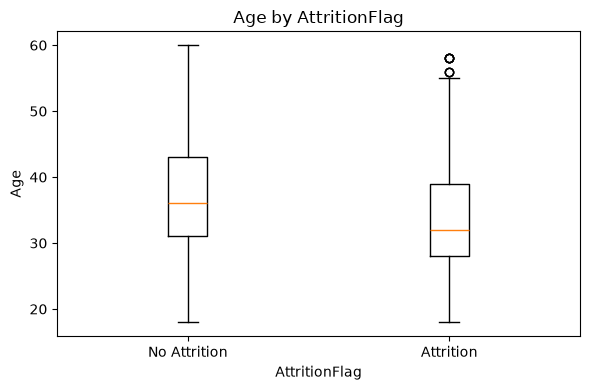

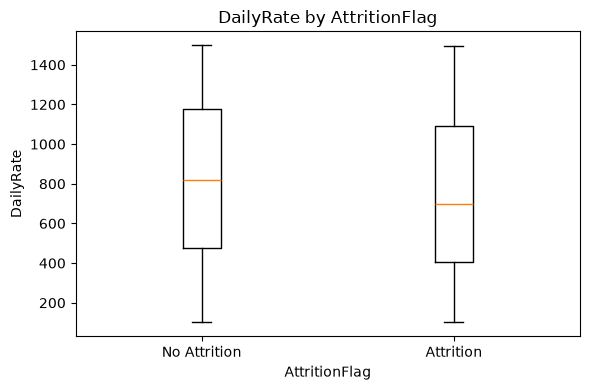

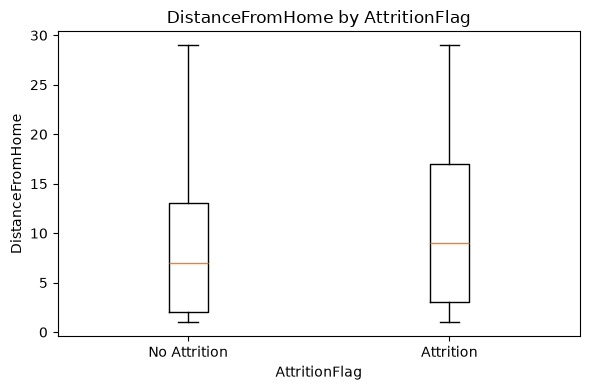

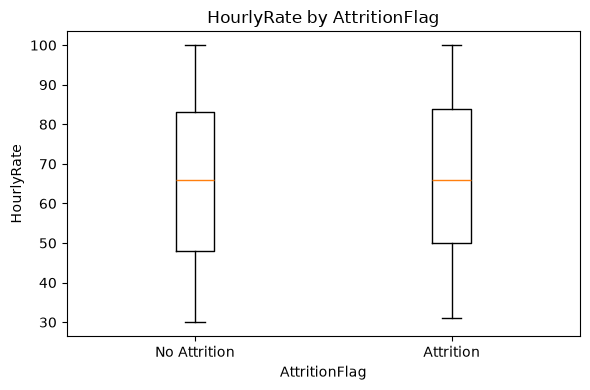

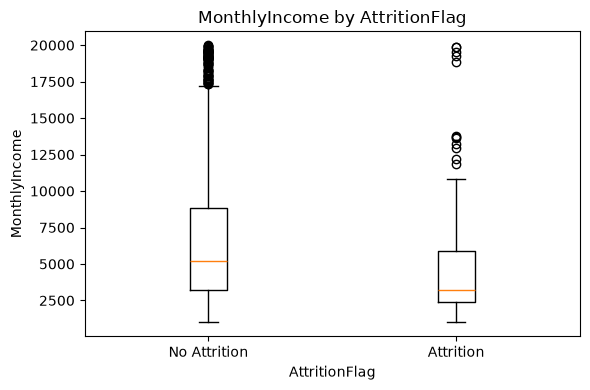

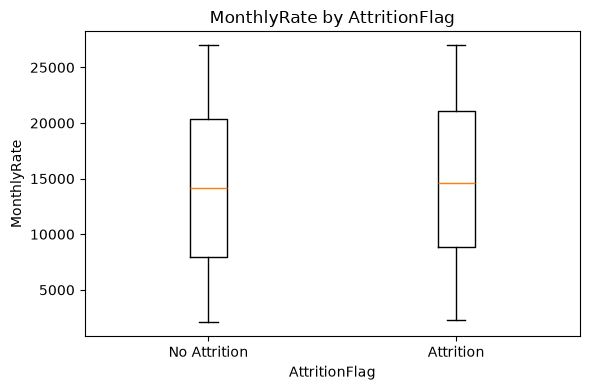

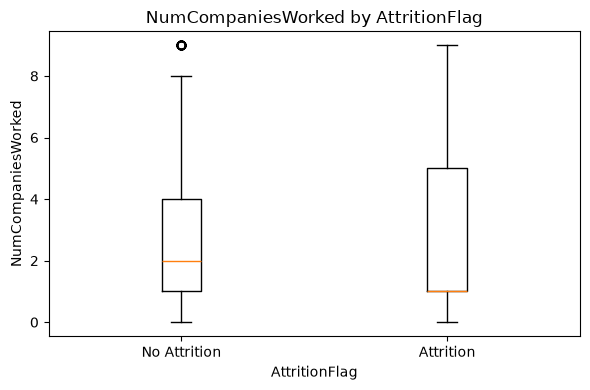

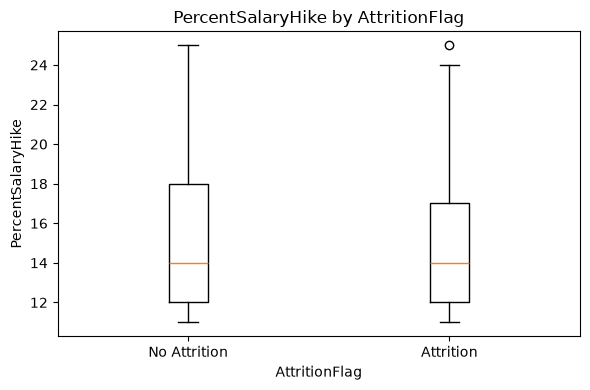

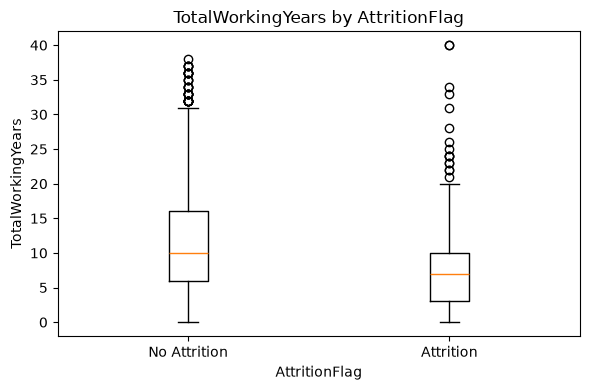

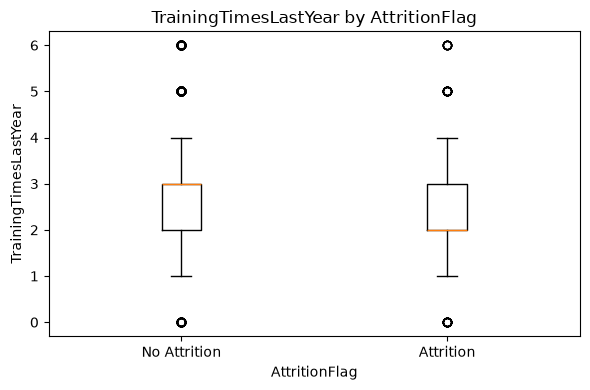

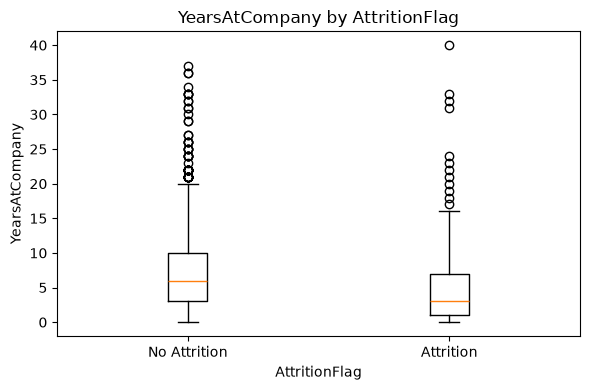

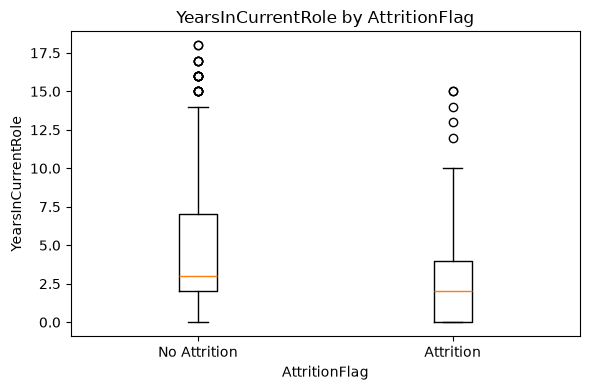

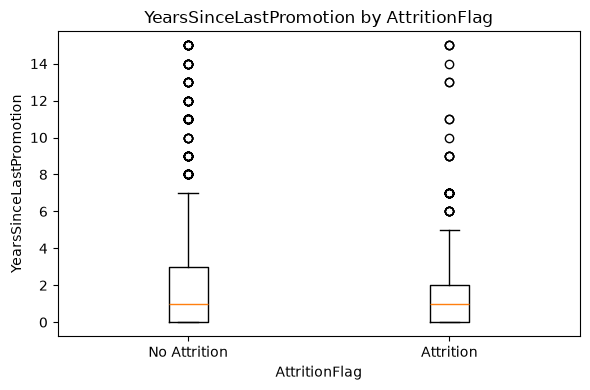

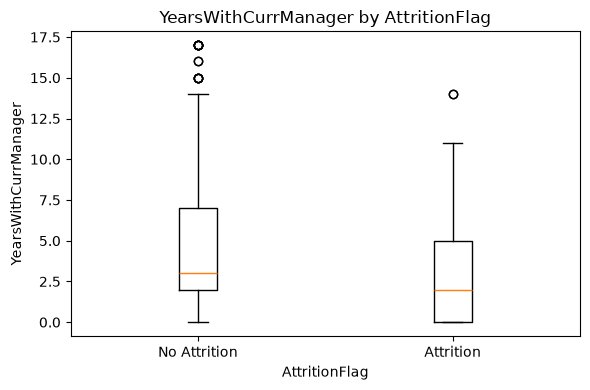

In [3]:
for col in quantitative_vars:
    if col != target:
        temp_df = df[[col, target]].dropna()

        group_0 = temp_df[temp_df[target] == 0][col]
        group_1 = temp_df[temp_df[target] == 1][col]

        plt.figure(figsize=(6, 4))
        plt.boxplot([group_0, group_1], tick_labels=["No Attrition", "Attrition"])

        plt.title(f"{col} by {target}")
        plt.xlabel(target)
        plt.ylabel(col)

        plt.tight_layout()
        plt.show()

In [4]:
correlation_table(df)

,Feature,Correlation,Abs_Correlation,p_value,Significativo,Association
0,TotalWorkingYears,-0.199,0.199,0.0000,Sim,Fraca
1,MonthlyIncome,-0.198,0.198,0.0000,Sim,Fraca
2,YearsAtCompany,-0.190,0.190,0.0000,Sim,Fraca
3,YearsInCurrentRole,-0.181,0.181,0.0000,Sim,Fraca
4,YearsWithCurrManager,-0.175,0.175,0.0000,Sim,Fraca
5,Age,-0.171,0.171,0.0000,Sim,Fraca
6,DistanceFromHome,0.079,0.079,0.0024,Sim,Fraca
7,DailyRate,-0.057,0.057,0.0289,Sim,Fraca
8,YearsSinceLastPromotion,-0.053,0.053,0.0411,Sim,Fraca
9,TrainingTimesLastYear,-0.052,0.052,0.0473,Sim,Fraca


In [5]:
predictors_table = quantitative_predictors_corr_table(df, quantitative_vars)

predictors_table

,Variable_1,Variable_2,Correlation,Abs_Correlation,p_value,Significativo,Association
0,YearsAtCompany,YearsInCurrentRole,0.854,0.854,0.0000,Sim,Muito forte
1,YearsAtCompany,YearsWithCurrManager,0.843,0.843,0.0000,Sim,Muito forte
2,YearsInCurrentRole,YearsWithCurrManager,0.725,0.725,0.0000,Sim,Muito forte
3,MonthlyIncome,TotalWorkingYears,0.710,0.710,0.0000,Sim,Muito forte
4,Age,TotalWorkingYears,0.657,0.657,0.0000,Sim,Forte
...,...,...,...,...,...,...,...
86,DistanceFromHome,MonthlyIncome,0.003,0.003,0.9233,Não,Fraca
87,TrainingTimesLastYear,YearsAtCompany,0.001,0.001,0.9576,Não,Fraca
88,Age,TrainingTimesLastYear,0.000,0.000,0.9903,Não,Fraca
89,HourlyRate,TrainingTimesLastYear,0.000,0.000,0.9911,Não,Fraca


In [6]:
strong_and_moderate_corr = predictors_table[predictors_table["Correlation"] >= 0.30]

strong_and_moderate_corr

,Variable_1,Variable_2,Correlation,Abs_Correlation,p_value,Significativo,Association
0,YearsAtCompany,YearsInCurrentRole,0.854,0.854,0.0,Sim,Muito forte
1,YearsAtCompany,YearsWithCurrManager,0.843,0.843,0.0,Sim,Muito forte
2,YearsInCurrentRole,YearsWithCurrManager,0.725,0.725,0.0,Sim,Muito forte
3,MonthlyIncome,TotalWorkingYears,0.710,0.710,0.0,Sim,Muito forte
4,Age,TotalWorkingYears,0.657,0.657,0.0,Sim,Forte
5,TotalWorkingYears,YearsAtCompany,0.594,0.594,0.0,Sim,Forte
6,YearsAtCompany,YearsSinceLastPromotion,0.520,0.520,0.0,Sim,Forte
7,YearsInCurrentRole,YearsSinceLastPromotion,0.506,0.506,0.0,Sim,Forte
8,TotalWorkingYears,YearsWithCurrManager,0.495,0.495,0.0,Sim,Moderada
9,TotalWorkingYears,YearsInCurrentRole,0.493,0.493,0.0,Sim,Moderada


In [7]:
vif_quantitative_table(df)

,Feature,VIF,Multicollinearity
0,TotalWorkingYears,4.646,Baixa
1,YearsAtCompany,4.564,Baixa
2,YearsWithCurrManager,2.748,Baixa
3,YearsInCurrentRole,2.685,Baixa
4,MonthlyIncome,2.529,Baixa
5,Age,1.990,Baixa
6,YearsSinceLastPromotion,1.669,Baixa
7,NumCompaniesWorked,1.243,Baixa
8,DailyRate,1.010,Baixa
9,MonthlyRate,1.008,Baixa


In [8]:
quantitative_models, quantitative_results = run_logistic_models(
    df=df,
    models_vars_dict=QUANTITATIVE_MODEL_VARS,
    target="AttritionFlag",
    categorical=False,
    show_summary=False
)

In [9]:
quantitative_comparison = compare_logistic_models(quantitative_models)

display(quantitative_comparison.round(4))

,Model,N_Observations,Df_Model,Log_Likelihood,LL_Null,LLR_p_value,AIC,BIC,Pseudo_R2
0,Modelo 1 — Experiência e Remuneração,1470,5,-611.8339,-649.2914,0.0,1235.6679,1267.4260,0.0577
1,Modelo 2 — Idade e Experiência,1470,5,-612.1048,-649.2914,0.0,1236.2096,1267.9677,0.0573
2,Modelo 4 — Reduzido Conservador,1470,5,-612.4226,-649.2914,0.0,1236.8453,1268.6034,0.0568
3,Modelo 3 — Antiguidade Organizacional,1470,5,-618.7627,-649.2914,0.0,1249.5253,1281.2834,0.0470


# Modelo 1 — Experiência e Remuneração

Este modelo foi construído para avaliar variáveis associadas à trajetória profissional e à remuneração do funcionário, utilizando `TotalWorkingYears` e `MonthlyIncome` como eixos principais. A proposta é testar se a experiência acumulada e o rendimento mensal acrescentam informação à explicação da saída dos funcionários, em conjunto com variáveis de deslocamento, remuneração diária e formação.

**Variáveis do modelo:** `TotalWorkingYears`, `MonthlyIncome`, `DistanceFromHome`, `DailyRate`, `TrainingTimesLastYear`.

In [10]:
quantitative_results["Modelo 1 — Experiência e Remuneração"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
DistanceFromHome,0.2146,1.2393,1.0809,1.4210,0.0021
DailyRate,-0.1473,0.8630,0.7480,0.9957,0.0435
TrainingTimesLastYear,-0.1768,0.8379,0.7239,0.9699,0.0178
MonthlyIncome,-0.3038,0.7380,0.5595,0.9735,0.0316
TotalWorkingYears,-0.4100,0.6636,0.5118,0.8604,0.0020
Intercept,-1.8132,0.1631,0.1387,0.1919,0.0000


# Modelo 2 — Idade e Experiência

Este modelo considera a idade e a experiência profissional do funcionário, representadas por `Age` e `TotalWorkingYears`. O objetivo é avaliar se características ligadas ao ciclo de carreira contribuem para explicar o attrition quando analisadas em conjunto com variáveis complementares de trabalho.

**Variáveis do modelo:** `Age`, `TotalWorkingYears`, `DistanceFromHome`, `DailyRate`, `TrainingTimesLastYear`.

In [11]:
quantitative_results["Modelo 2 — Idade e Experiência"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
DistanceFromHome,0.2147,1.2395,1.0807,1.4215,0.0021
DailyRate,-0.1476,0.8627,0.7475,0.9958,0.0436
TrainingTimesLastYear,-0.1739,0.8404,0.7264,0.9723,0.0194
Age,-0.2050,0.8146,0.6674,0.9943,0.0438
TotalWorkingYears,-0.4702,0.6249,0.4939,0.7906,0.0001
Intercept,-1.7997,0.1653,0.1410,0.1938,0.0000


# Modelo 3 — Antiguidade Organizacional

Este modelo é focado na permanência do funcionário dentro da empresa, utilizando `YearsAtCompany` como variável principal. Também inclui `YearsSinceLastPromotion`, permitindo testar se o tempo na organização e o período desde a última promoção acrescentam informação à explicação da saída dos funcionários.

**Variáveis do modelo:** `YearsAtCompany`, `DistanceFromHome`, `DailyRate`, `TrainingTimesLastYear`, `YearsSinceLastPromotion`.

In [12]:
quantitative_results["Modelo 3 — Antiguidade Organizacional"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
YearsSinceLastPromotion,0.3373,1.4012,1.1314,1.7354,0.0020
DistanceFromHome,0.2076,1.2307,1.0755,1.4084,0.0026
DailyRate,-0.1611,0.8512,0.7384,0.9812,0.0263
TrainingTimesLastYear,-0.1622,0.8503,0.7360,0.9823,0.0277
YearsAtCompany,-0.7621,0.4667,0.3581,0.6083,0.0000
Intercept,-1.7841,0.1680,0.1434,0.1967,0.0000


# Modelo 4 — Reduzido Conservador

Este modelo reúne um conjunto mais simples e conservador de variáveis quantitativas significativas, evitando a inclusão conjunta de variáveis de tempo altamente correlacionadas. Serve como referência para comparação com os modelos quantitativos centrados em blocos específicos.

**Variáveis do modelo:** `TotalWorkingYears`, `DistanceFromHome`, `DailyRate`, `TrainingTimesLastYear`, `YearsSinceLastPromotion`.

In [13]:
quantitative_results["Modelo 4 — Reduzido Conservador"].round(4)

,Coefficient,Odds_Ratio,CI_Lower,CI_Upper,p_value
DistanceFromHome,0.2142,1.2389,1.0804,1.4207,0.0022
YearsSinceLastPromotion,0.1744,1.1905,0.9974,1.4210,0.0535
DailyRate,-0.1427,0.8670,0.7513,1.0004,0.0507
TrainingTimesLastYear,-0.1758,0.8387,0.7251,0.9702,0.0180
TotalWorkingYears,-0.7061,0.4935,0.3987,0.6110,0.0000
Intercept,-1.8065,0.1642,0.1399,0.1929,0.0000
